## Variational Encoder

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility 
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def plot_username():
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)

Using device: cuda


### 4.2 Dataset Preparation

In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),                      # [0,1]
    transforms.Normalize((0.5,), (0.5,))        # mean=0.5, std=0.5 ⇒ roughly [-1,1]
])

train_dataset = datasets.FashionMNIST(
    root="/kaggle/working/data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="/kaggle/working/data",
    train=False,
    transform=transform,
    download=True
)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset), "Test size:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]

Train size: 60000 Test size: 10000


### 4.3 Model Architecture

In [3]:
latent_dim = 2  # change this to experiment with different latent sizes
input_dim = 28 * 28
hidden_dim = 256

class Encoder(nn.Module):
    """Encodes input x into μ and logσ² parameters of the VAE latent distribution q(z|x)."""

    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = x.view(x.size(0), -1)     # flatten
        h = self.net(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar


In [4]:
def reparameterize(mu, logvar):
    """
    z = mu + eps * sigma,  eps ~ N(0, I)
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [5]:
class Decoder(nn.Module):
    """
    Decodes latent vector z into output image x̂. 
       Implements the generative part of the VAE.
    """
    def __init__(self, latent_dim=2, hidden_dim=256, output_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
            nn.Sigmoid()  # output in [0,1] to match BCE assumption
        )

    def forward(self, z):
        x_hat = self.net(z)
        x_hat = x_hat.view(-1, 1, 28, 28)
        return x_hat


In [6]:
class VAE(nn.Module):
    """
    Full VAE combining encoder, reparameterization, and decoder.
    """
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar, z


In [7]:
vae = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)


### 4.4 Loss Function

In [8]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    """
    x, x_hat: (B, 1, 28, 28)
    BCE reconstruction + beta * KL
    """
    x = (x+1)/2  # Rescale x from [-1,1] to [0,1] for BCE loss
    # Reconstruction loss (sum over pixels & batch)
    recon_loss = F.binary_cross_entropy(
        x_hat, x, reduction='sum'
    )

    # KL divergence between q(z|x) and N(0, I)
    # D_KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total = recon_loss + beta * kld
    return total, recon_loss, kld


### 4.5 Training Procedure

In [9]:
def train_vae(model, train_loader, optimizer, epochs=20, beta=1.0):
    model.train()
    epoch_totals, epoch_recons, epoch_klds = [], [], []

    for epoch in range(1, epochs + 1):
        total_loss = 0
        total_recon = 0
        total_kld = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()
            x_hat, mu, logvar, _ = model(x)
            loss, recon, kld = vae_loss(x, x_hat, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kld += kld.item()

        N = len(train_loader.dataset)
        epoch_totals.append(total_loss / N)
        epoch_recons.append(total_recon / N)
        epoch_klds.append(total_kld / N)

        print(f"Epoch [{epoch}/{epochs}] "
              f"Total: {epoch_totals[-1]:.4f} "
              f"Recon: {epoch_recons[-1]:.4f} "
              f"KLD: {epoch_klds[-1]:.4f}")

    return epoch_totals, epoch_recons, epoch_klds


In [10]:
epochs = 15
beta = 1.0

vae = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

totals, recons, klds = train_vae(vae, train_loader, optimizer, epochs=epochs, beta=beta)


Epoch [1/15] Total: 285.8293 Recon: 279.9683 KLD: 5.8610
Epoch [2/15] Total: 267.5285 Recon: 261.5802 KLD: 5.9483
Epoch [3/15] Total: 264.3556 Recon: 258.3478 KLD: 6.0078
Epoch [4/15] Total: 262.5092 Recon: 256.4619 KLD: 6.0473
Epoch [5/15] Total: 261.3033 Recon: 255.2146 KLD: 6.0887
Epoch [6/15] Total: 260.4296 Recon: 254.3107 KLD: 6.1189
Epoch [7/15] Total: 259.6709 Recon: 253.5053 KLD: 6.1656
Epoch [8/15] Total: 258.9669 Recon: 252.7308 KLD: 6.2361
Epoch [9/15] Total: 258.5458 Recon: 252.2768 KLD: 6.2690
Epoch [10/15] Total: 257.7171 Recon: 251.4019 KLD: 6.3151
Epoch [11/15] Total: 257.3269 Recon: 250.9783 KLD: 6.3486
Epoch [12/15] Total: 256.9499 Recon: 250.5468 KLD: 6.4031
Epoch [13/15] Total: 256.5194 Recon: 250.0905 KLD: 6.4289
Epoch [14/15] Total: 256.0869 Recon: 249.6334 KLD: 6.4535
Epoch [15/15] Total: 255.8382 Recon: 249.3660 KLD: 6.4722


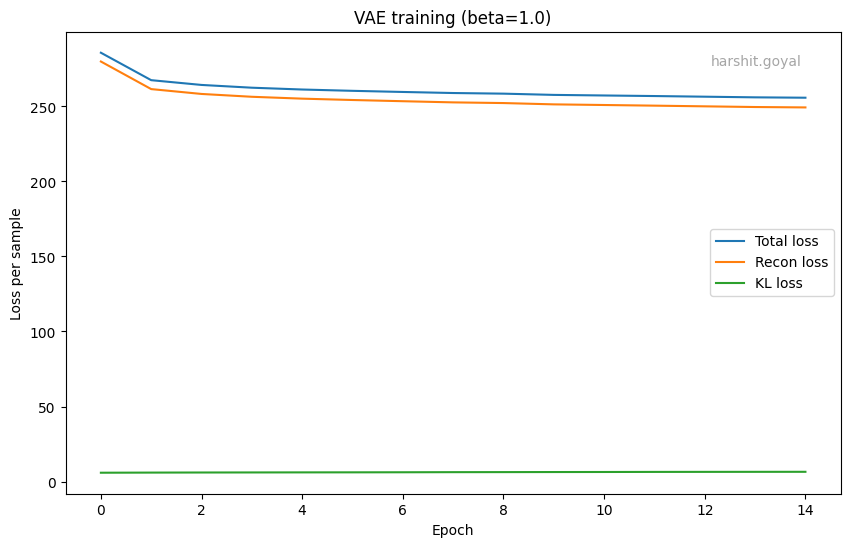

In [11]:
plt.figure(figsize=(10,6))
plt.plot(totals, label='Total loss')
plt.plot(recons, label='Recon loss')
plt.plot(klds, label='KL loss')
plt.xlabel('Epoch')
plt.ylabel('Loss per sample')
plt.legend()
plot_username()
plt.title(f'VAE training (beta={beta})')
plt.show()


### 4.6 Experimental Analysis


In [12]:
betas = [0.1, 0.5, 1.0]


In [13]:
# 0 T-shirt/top
# 1 Trouser
# 2 Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot

classes_to_show = [0, 5, 9]   # T-shirt, Sandal, Ankle boot
class_names = train_dataset.classes
print("Chosen classes:", [class_names[c] for c in classes_to_show])


Chosen classes: ['T-shirt/top', 'Sandal', 'Ankle boot']


In [14]:
def get_latents_for_classes(model, loader, classes, max_samples_per_class=300):
    model.eval()
    zs = []
    ys = []

    counts = {c: 0 for c in classes}

    with torch.no_grad():
        for x, y in loader:
            mask = torch.zeros_like(y, dtype=torch.bool)
            for c in classes:
                mask |= (y == c)

            x = x[mask].to(device)
            y = y[mask]

            if x.size(0) == 0:
                continue

            _, mu, logvar, z = model(x)

            zs.append(z.cpu())
            ys.append(y.cpu())

            for c in classes:
                counts[c] += (y == c).sum().item()

            if all(counts[c] >= max_samples_per_class for c in classes):
                break

    zs = torch.cat(zs, dim=0)
    ys = torch.cat(ys, dim=0)
    return zs.numpy(), ys.numpy()



Training β-VAE with β = 0.1

Epoch [1/12] Total: 276.8930 Recon: 275.4794 KLD: 14.1358
Epoch [2/12] Total: 259.0474 Recon: 257.8779 KLD: 11.6953
Epoch [3/12] Total: 256.2928 Recon: 255.1809 KLD: 11.1193
Epoch [4/12] Total: 254.8069 Recon: 253.7236 KLD: 10.8328
Epoch [5/12] Total: 253.5898 Recon: 252.5106 KLD: 10.7922
Epoch [6/12] Total: 252.5480 Recon: 251.4719 KLD: 10.7609
Epoch [7/12] Total: 251.7153 Recon: 250.6456 KLD: 10.6971
Epoch [8/12] Total: 251.0230 Recon: 249.9547 KLD: 10.6835
Epoch [9/12] Total: 250.4635 Recon: 249.4071 KLD: 10.5643
Epoch [10/12] Total: 250.1151 Recon: 249.0633 KLD: 10.5178
Epoch [11/12] Total: 249.7247 Recon: 248.6717 KLD: 10.5301
Epoch [12/12] Total: 249.4003 Recon: 248.3538 KLD: 10.4647


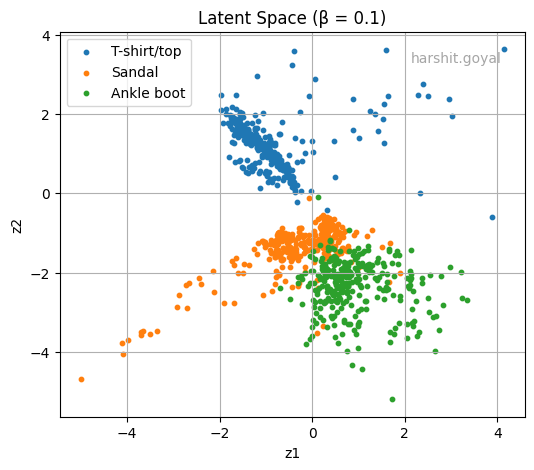


Training β-VAE with β = 0.5

Epoch [1/12] Total: 279.0936 Recon: 275.3054 KLD: 7.5763
Epoch [2/12] Total: 263.0535 Recon: 259.5086 KLD: 7.0898
Epoch [3/12] Total: 260.0687 Recon: 256.5070 KLD: 7.1233
Epoch [4/12] Total: 258.4913 Recon: 254.9361 KLD: 7.1103
Epoch [5/12] Total: 257.4695 Recon: 253.8956 KLD: 7.1479
Epoch [6/12] Total: 256.2707 Recon: 252.7077 KLD: 7.1261
Epoch [7/12] Total: 255.4787 Recon: 251.8962 KLD: 7.1651
Epoch [8/12] Total: 254.7639 Recon: 251.1605 KLD: 7.2068
Epoch [9/12] Total: 254.1485 Recon: 250.5304 KLD: 7.2363
Epoch [10/12] Total: 253.5557 Recon: 249.9163 KLD: 7.2789
Epoch [11/12] Total: 253.0636 Recon: 249.4085 KLD: 7.3103
Epoch [12/12] Total: 252.7238 Recon: 249.0617 KLD: 7.3242


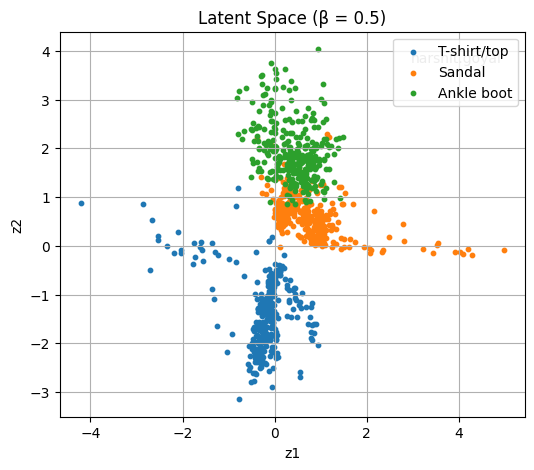


Training β-VAE with β = 1.0

Epoch [1/12] Total: 283.8873 Recon: 277.7678 KLD: 6.1195
Epoch [2/12] Total: 266.3032 Recon: 260.2249 KLD: 6.0782
Epoch [3/12] Total: 263.0822 Recon: 256.9563 KLD: 6.1259
Epoch [4/12] Total: 261.5401 Recon: 255.3740 KLD: 6.1661
Epoch [5/12] Total: 260.5090 Recon: 254.3164 KLD: 6.1926
Epoch [6/12] Total: 259.5611 Recon: 253.2970 KLD: 6.2641
Epoch [7/12] Total: 258.7895 Recon: 252.4839 KLD: 6.3056
Epoch [8/12] Total: 258.3615 Recon: 252.0228 KLD: 6.3387
Epoch [9/12] Total: 257.7748 Recon: 251.4432 KLD: 6.3316
Epoch [10/12] Total: 257.1664 Recon: 250.7712 KLD: 6.3951
Epoch [11/12] Total: 256.8956 Recon: 250.4885 KLD: 6.4071
Epoch [12/12] Total: 256.3647 Recon: 249.9317 KLD: 6.4331


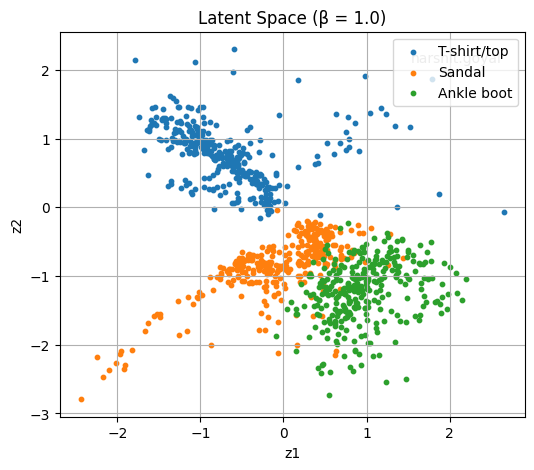

In [15]:
results = []

for beta in betas:
    print("\n===============================")
    print(f"Training β-VAE with β = {beta}")
    print("===============================\n")

    vae_beta = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
    optimizer_beta = torch.optim.Adam(vae_beta.parameters(), lr=1e-3)

    totals, recons, klds = train_vae(
        vae_beta, train_loader, optimizer_beta,
        epochs=12,   # 12–15 is enough for latent visualization
        beta=beta
    )

    # Save final metrics
    results.append({
        "beta": beta,
        "total_loss": totals[-1],
        "recon_loss": recons[-1],
        "kl_loss": klds[-1],
    })

    # ----- LATENT SPACE VISUALIZATION -----
    z_vals, y_vals = get_latents_for_classes(
        vae_beta, test_loader, classes_to_show)

    plt.figure(figsize=(6, 5))
    for c in classes_to_show:
        mask = (y_vals == c)
        plt.scatter(z_vals[mask, 0], z_vals[mask, 1], s=10, label=class_names[c])

    plt.title(f"Latent Space (β = {beta})")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend()
    plot_username()
    plt.grid(True)
    plt.show()


In [16]:
print("\n===== β-VAE Results Summary =====")
for r in results:
    print(f"β={r['beta']}:  Total={r['total_loss']:.3f},  Recon={r['recon_loss']:.3f},  KL={r['kl_loss']:.3f}")



===== β-VAE Results Summary =====
β=0.1:  Total=249.400,  Recon=248.354,  KL=10.465
β=0.5:  Total=252.724,  Recon=249.062,  KL=7.324
β=1.0:  Total=256.365,  Recon=249.932,  KL=6.433


### 4.7  Evaluation and Visualization

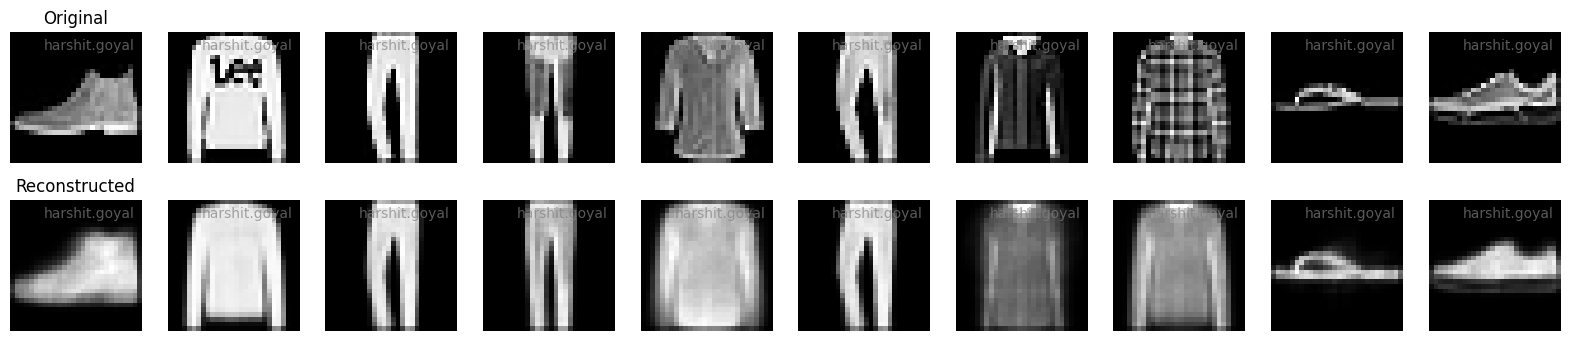

In [17]:
def show_reconstructions(model, loader, num_images=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)

    with torch.no_grad():
        x_hat, _, _,_ = model(x)

    # Unnormalize x for visualization if normalized
    x_vis = (x + 1) / 2     # [-1,1] → [0,1]

    x_hat = x_hat.cpu()
    x_vis = x_vis.cpu()

    plt.figure(figsize=(num_images * 2, 4))

    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(x_vis[i, 0], cmap='gray')
        plot_username()
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        # Reconstruction
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(x_hat[i, 0], cmap='gray')
        plot_username()
        plt.axis("off")
        if i == 0:
            plt.title("Reconstructed")

    plt.show()


# Show reconstructions for your best trained model (β=1 or β=0.5)
show_reconstructions(vae, test_loader, num_images=10)


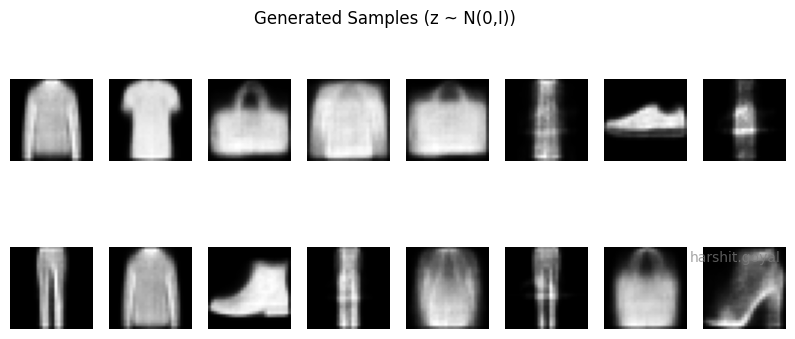

In [22]:
def sample_new_images(model, num_samples=20):
    model.eval()
    latent_dim = model.latent_dim

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        x_gen = model.decoder(z).cpu()

    plt.figure(figsize=(10, 4))
    for i in range(num_samples):
        plt.subplot(2, num_samples//2, i + 1)
        plt.imshow(x_gen[i, 0], cmap='gray')
        plt.axis("off")
    plt.suptitle("Generated Samples (z ~ N(0,I))")
    plot_username()
    plt.show()


sample_new_images(vae, num_samples=16)


In [23]:
class FeatureExtractor(nn.Module):
    """Extracts 1280-D image features using EfficientNet-B0 for FID."""
    def __init__(self):
        super().__init__()
        base = efficientnet_b0(weights="IMAGENET1K_V1")
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.output_dim = 1280   # EfficientNet-B0 final feature size
        self.eval()

    def forward(self, x):
        # EfficientNet expects 224×224
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        feat = self.features(x)
        feat = self.pool(feat)
        return feat.view(feat.size(0), -1)


def compute_fid(model, loader, num_batches=10):
    model.eval()
    extractor = FeatureExtractor().to(device)

    real_feats = []
    fake_feats = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= num_batches:
                break

            # ------------ REAL IMAGES -------------
            x_real = (x.to(device) + 1) / 2         # [-1,1] -> [0,1]
            x_real = x_real.repeat(1, 3, 1, 1)      # grayscale -> RGB
            f_real = extractor(x_real).cpu()
            real_feats.append(f_real)

            # ------------ FAKE IMAGES -------------
            z = torch.randn(x.size(0), model.latent_dim).to(device)
            x_fake = model.decoder(z)
            x_fake = (x_fake + 1) / 2
            x_fake = x_fake.repeat(1, 3, 1, 1)
            f_fake = extractor(x_fake).cpu()
            fake_feats.append(f_fake)

    # Concatenate feature batches
    real_feats = torch.cat(real_feats, dim=0).numpy()
    fake_feats = torch.cat(fake_feats, dim=0).numpy()

    # Compute means & variances
    mu_real = real_feats.mean(axis=0)
    mu_fake = fake_feats.mean(axis=0)
    sigma_real = real_feats.var(axis=0)
    sigma_fake = fake_feats.var(axis=0)

    # FAST FID metric (no sqrtm)
    fid = ((mu_real - mu_fake) ** 2).sum() + ((sigma_real - sigma_fake) ** 2).sum()
    return fid


fid_score = compute_fid(vae, test_loader, num_batches=10)
print("FID Score:", fid_score)


FID Score: 84.7156


### 4.8 Effect of Frozen Latent Parameters

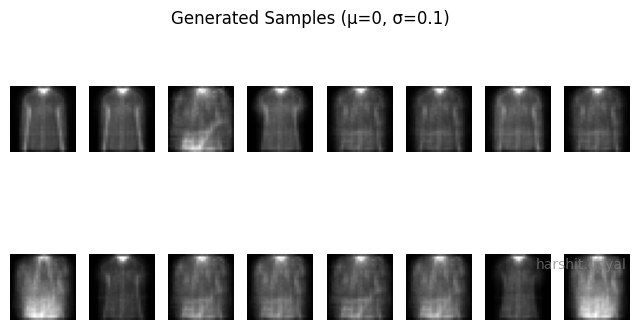

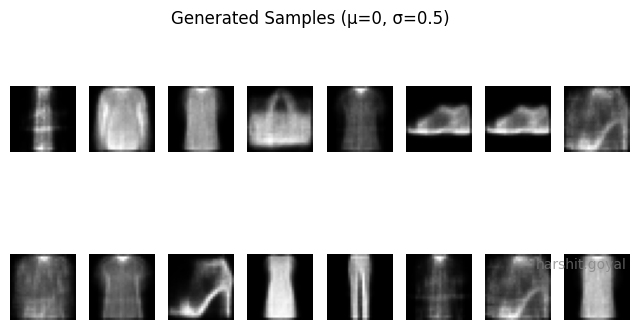

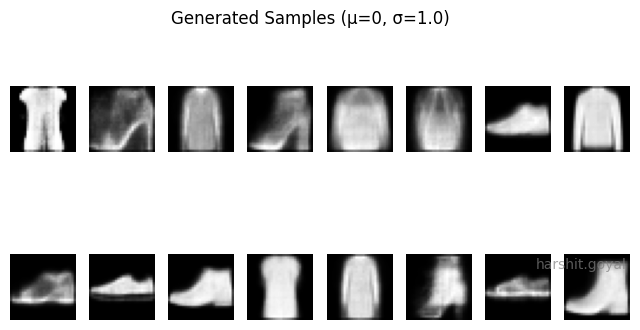

In [24]:
def generate_with_fixed_sigma(model, sigma_list=[0.1, 0.5, 1.0], num_samples=16):
    model.eval()
    latent_dim = model.latent_dim

    for sigma in sigma_list:
        with torch.no_grad():
            z = torch.randn(num_samples, latent_dim).to(device) * sigma   # μ=0, σ=sigma
            x_gen = model.decoder(z).cpu()

        plt.figure(figsize=(8, 4))
        for i in range(num_samples):
            plt.subplot(2, num_samples//2, i+1)
            plt.imshow(x_gen[i, 0], cmap='gray')
            plt.axis("off")
        plt.suptitle(f"Generated Samples (μ=0, σ={sigma})")
        plot_username()
        plt.show()


# Run experiment A
generate_with_fixed_sigma(vae, sigma_list=[0.1, 0.5, 1.0], num_samples=16)


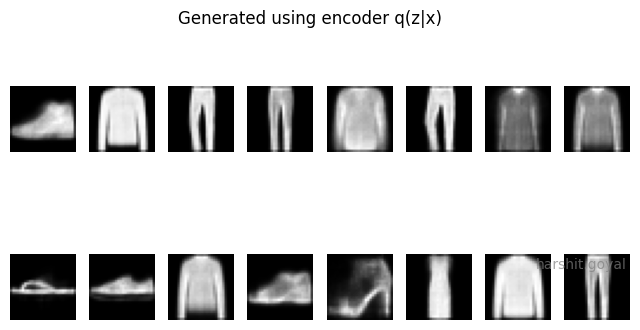

In [25]:
def generate_from_encoder(model, loader, num_samples=16):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)

    with torch.no_grad():
        _, mu, logvar, z = model(x)     # uses your full VAE forward
        x_gen = model.decoder(z).cpu()

    plt.figure(figsize=(8, 4))
    for i in range(num_samples):
        plt.subplot(2, num_samples//2, i+1)
        plt.imshow(x_gen[i, 0], cmap='gray')
        plt.axis("off")
    plt.suptitle("Generated using encoder q(z|x)")
    plot_username()
    plt.show()


# Run experiment B
generate_from_encoder(vae, test_loader, num_samples=16)
